# Patient Mental Health — Exploratory Data Analysis

2,172 mental health patients (students + working professionals), ~40 features. Goal: understand distributions, depression predictors, and feature relationships before clustering.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import sys
sys.path.insert(0, '.')
import prep.eda as eda

# Patch save() to display inline rather than write PNG to disk
def _inline_save(fig, name):
    display(fig)
    plt.close(fig)

eda.save = _inline_save

df = pd.read_csv('data/data_clean.csv')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 2,556 rows × 40 columns


,patient_id,gender,age,city,status,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,...,city_lon,stress_index,wellbeing_score,physical_score,emotional_score,age_group,worklife_balance,high_risk,cgpa_band,treatment_not_needed
0,0,Female,37,Ghaziabad,Working Professional,Teacher,NaN,2.0,NaN,NaN,...,77.458697,2.000000,2.666667,1.5,0.75,31-40,0.833333,0,non_student,True
1,1,Male,60,Kalyan,Working Professional,Financial Analyst,NaN,4.0,NaN,NaN,...,73.136648,3.666667,1.666667,1.5,2.75,51+,1.000000,1,non_student,False
2,2,Female,42,Bhopal,Working Professional,Teacher,NaN,2.0,NaN,NaN,...,77.401989,2.333333,2.000000,2.0,1.00,41-50,1.000000,0,non_student,False
3,3,Female,44,Thane,Working Professional,Teacher,NaN,3.0,NaN,NaN,...,73.368544,2.333333,3.333333,2.0,2.00,41-50,0.972222,0,non_student,False
4,4,Male,48,Indore,Working Professional,UX/UI Designer,NaN,4.0,NaN,NaN,...,75.868200,3.666667,2.333333,1.5,2.75,41-50,0.833333,1,non_student,False


## Dataset Overview

The cleaned dataset contains 2,172 patients across ~40 columns. Roughly half are students and half are working professionals. Depression is the binary target (1 = depressed). Several composite features were engineered during cleaning: `stress_index`, `wellbeing_score`, `emotional_score`, `physical_score`, `worklife_balance`, and `high_risk`.

In [2]:
print("=== Schema ===")
df.info()
print("\n=== Student / Professional split ===")
print(df['status'].value_counts())
print("\n=== Depression prevalence ===")
print(df['depression'].value_counts(normalize=True).rename({0: 'No', 1: 'Yes'}).map('{:.1%}'.format))

=== Schema ===
<class 'pandas.DataFrame'>
RangeIndex: 2556 entries, 0 to 2555
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            2556 non-null   int64  
 1   gender                2556 non-null   str    
 2   age                   2556 non-null   int64  
 3   city                  2556 non-null   str    
 4   status                2556 non-null   str    
 5   profession            1883 non-null   str    
 6   academic_pressure     502 non-null    float64
 7   work_pressure         2054 non-null   float64
 8   cgpa                  502 non-null    float64
 9   study_satisfaction    502 non-null    float64
 10  job_satisfaction      2054 non-null   float64
 11  sleep_duration        2556 non-null   int64  
 12  dietary_habits        2556 non-null   str    
 13  degree                2556 non-null   str    
 14  suicidal_thoughts     2556 non-null   int64  
 15  workstudy_hours  

## Depression Distibution

The depression flag only is present of 17.8% of incoming patients. Since in the original dataset this was the target, here we will use it as a "history of depression" considering Charlie has Eating Disorder.

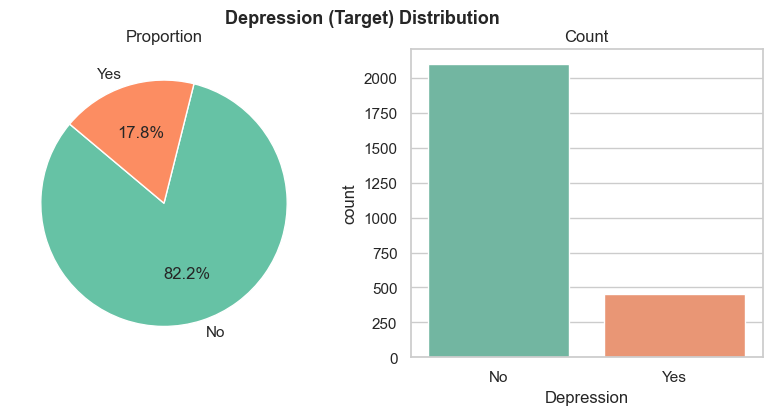

In [3]:
eda.plot_target(df)

## Age Distribution

Age spans roughly 18–60 almost uniformly. The age by depression KDE shows that the depression flag skews much younger.

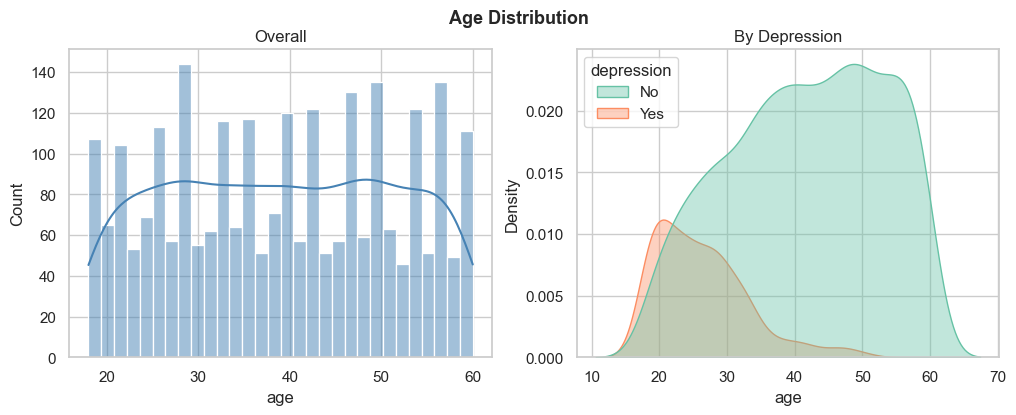

In [4]:
eda.plot_age(df)

## Depression Rate by Categorical Features

Depression affects gender in equal proportions (at least in this sample population, could be different IRL.). Age, dietary habits and sleep show a wide decline in depression as they go up. Students (conflates with age) are also way overrepresented in depression reporting

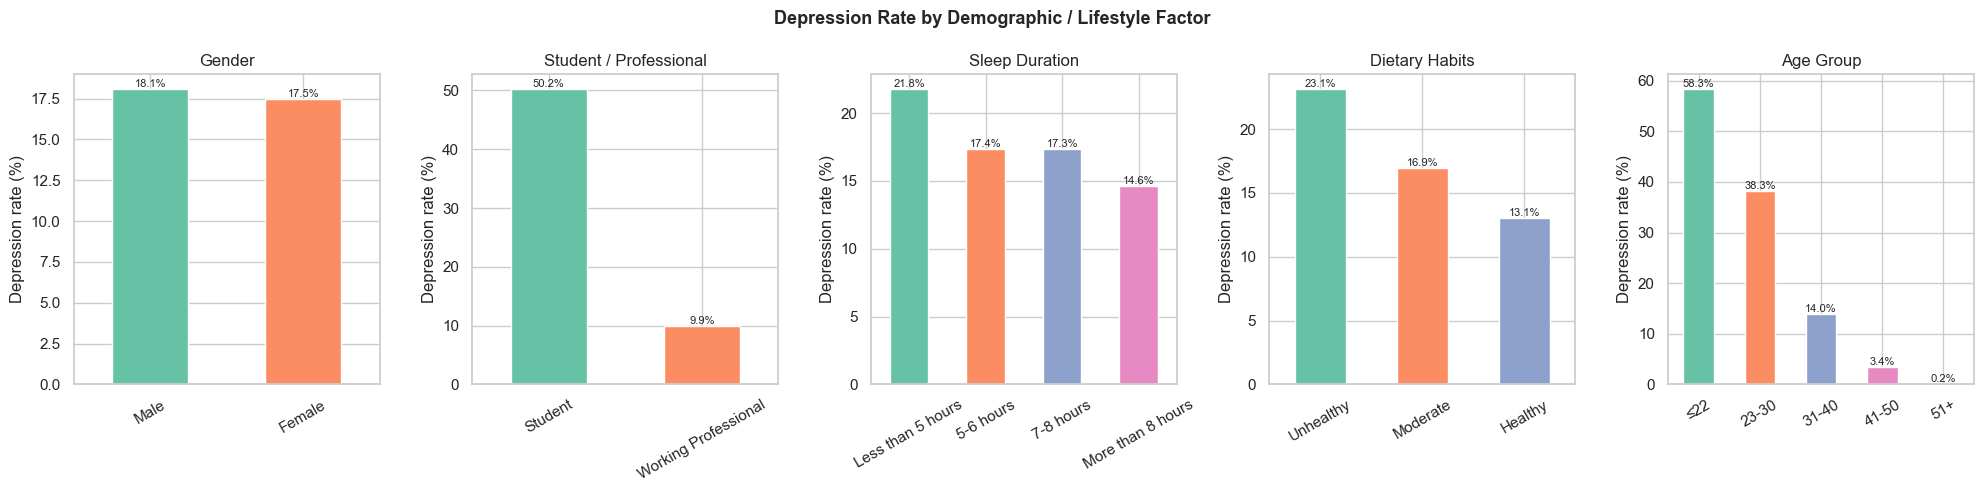

In [5]:
eda.plot_depression_by_categoricals(df)

## Numeric Features by Depression (Violin Plots)

When depression is present:
- pressure, financial stress, workstudy hours, and stress index tends to be higher
- satisfaction and wellbeing score tends to be lower



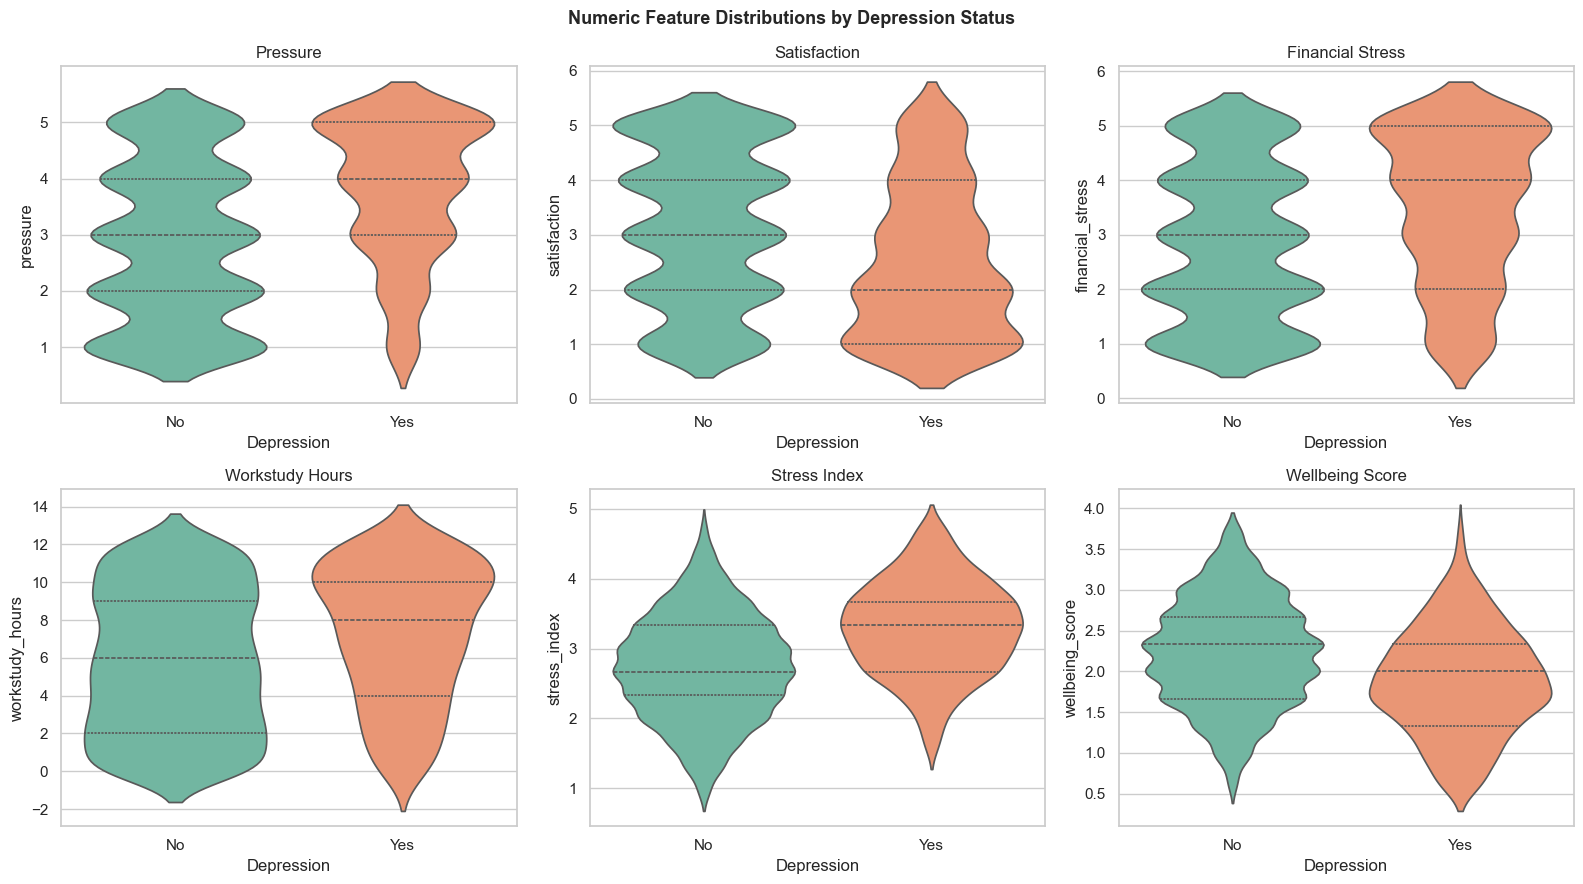

In [6]:
eda.plot_numeric_by_depression(df)

## Correlation Heatmap

Many of the raw features alone have little correlation


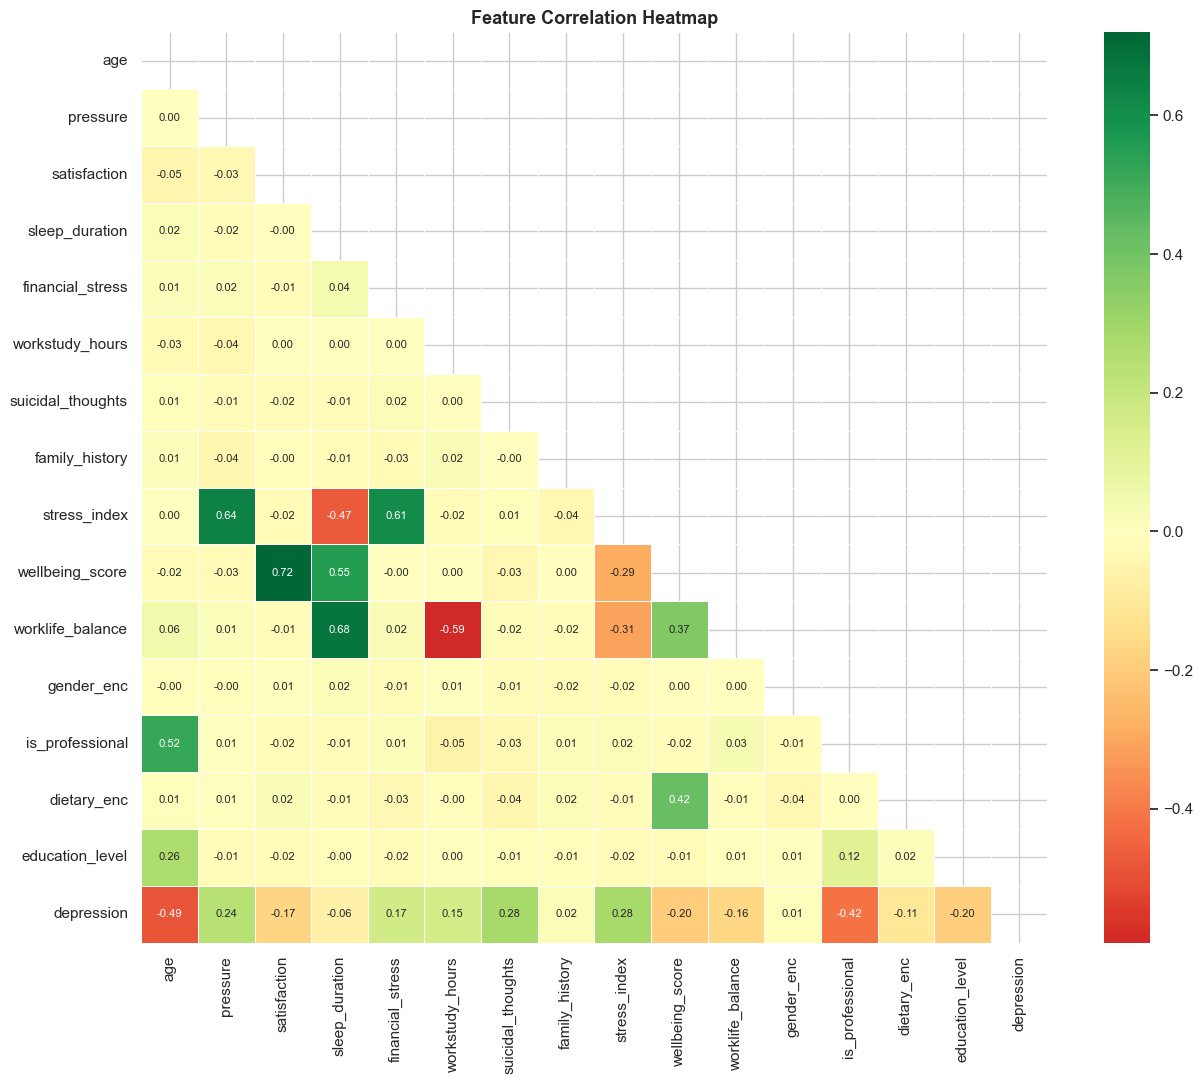

In [7]:
eda.plot_correlation(df)

## Stress vs Wellbeing Scatter

As expected when stress is high and well being is low, higher rate of depressions

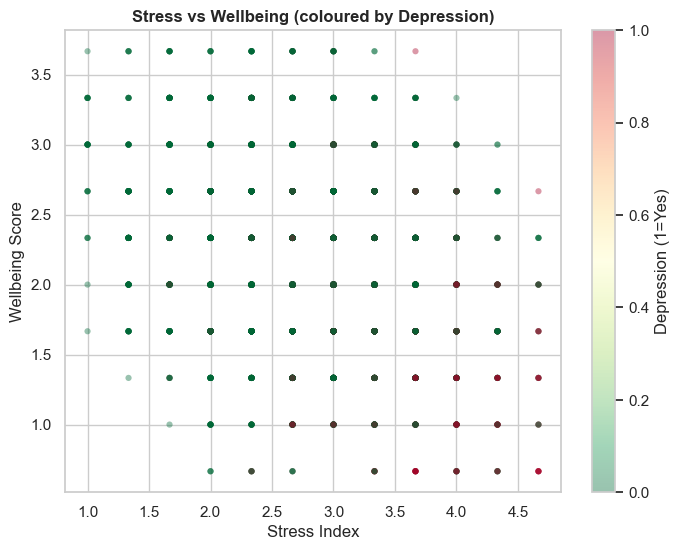

In [8]:
eda.plot_stress_vs_wellbeing(df)

## High-Risk Flag

The `high_risk` flag is engineered as a composite of suicidal thoughts, family history of mental illness, and severe stress. Its about 1/4 of the population

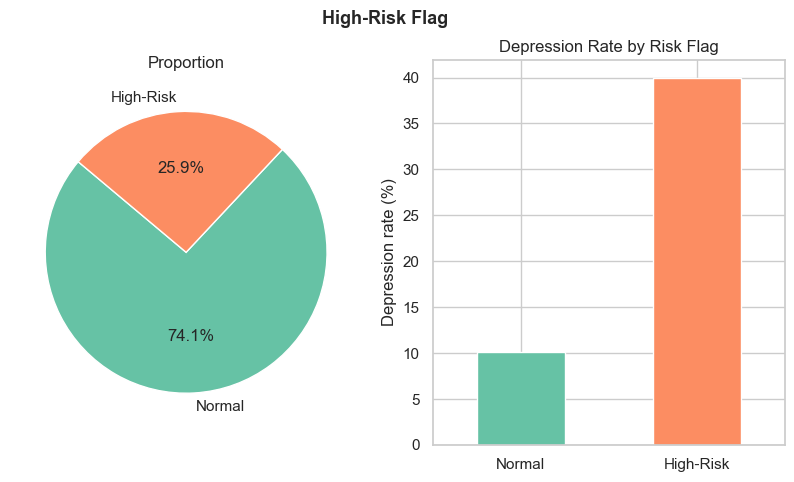

In [9]:
eda.plot_high_risk(df)

## Pairplot of Core Clustering Features

Pressure & Satisfaction have an inverse relationship

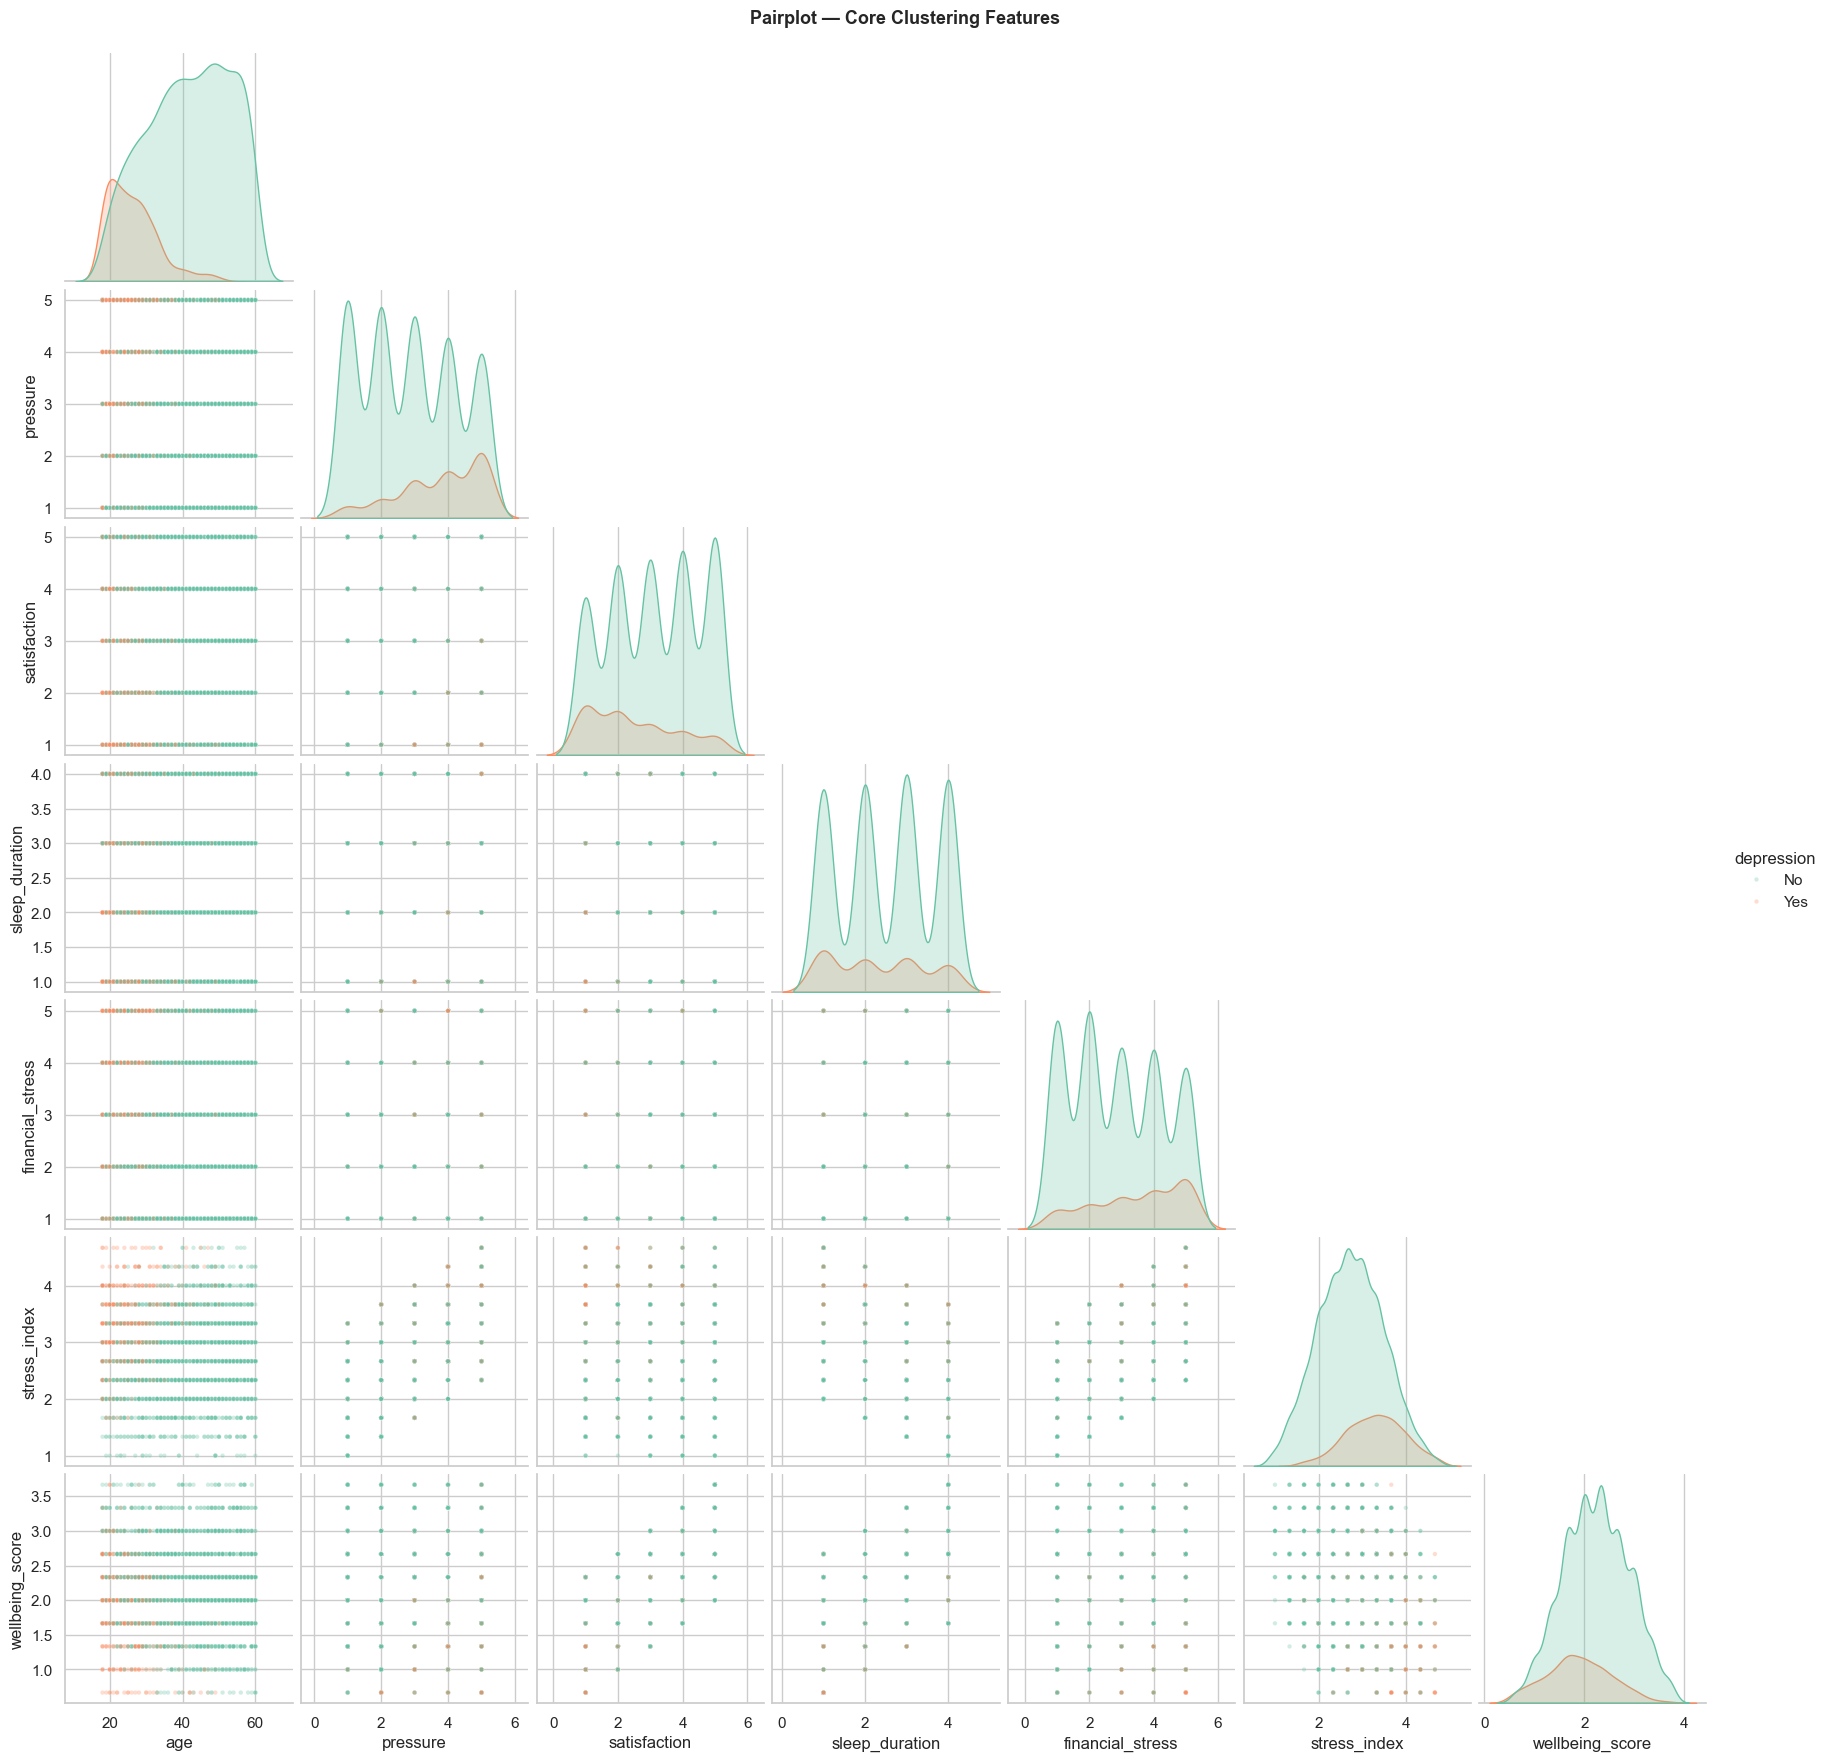

In [10]:
eda.plot_pairplot(df)

## Work/Study Hours by Status & Depression

Students generally report longer hours. Among both groups, depressed patients tend to report slightly more hours.

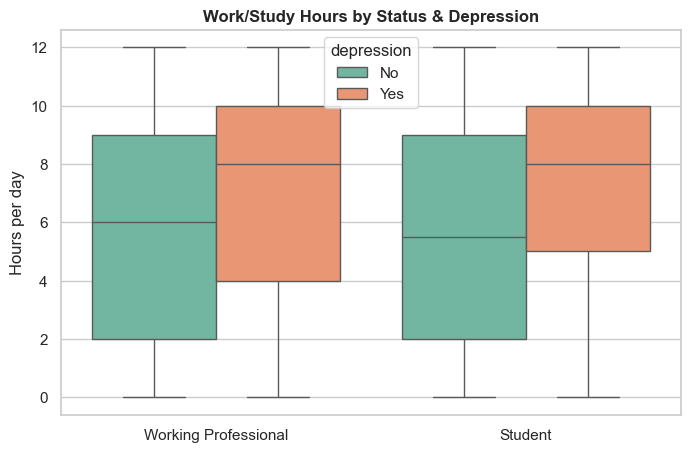

In [11]:
eda.plot_hours_by_status(df)

## Financial Stress Heatmap (Age Group × Status)

A heatmap of mean financial_stress by age group and student/professional status. Young students (18–22) typically show the highest financial stress — limited income combined with education costs. Mid-career professionals (35–44) often show lower financial stress.

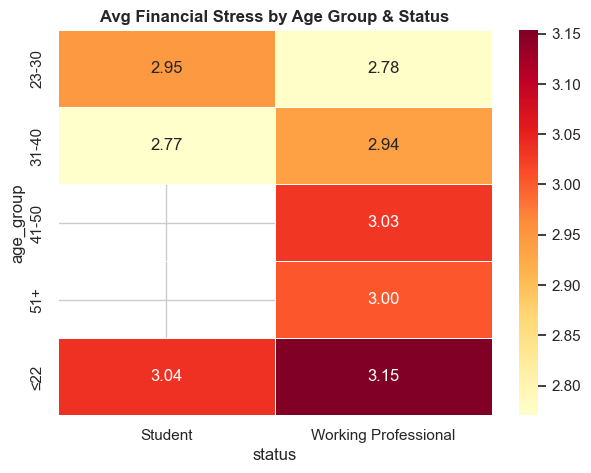

In [12]:
eda.plot_financial_stress_heatmap(df)

## Education Level

Portion of high school only is way overrepresented in depression rate probably because it skews very young. The average stress index is the same across education levels.

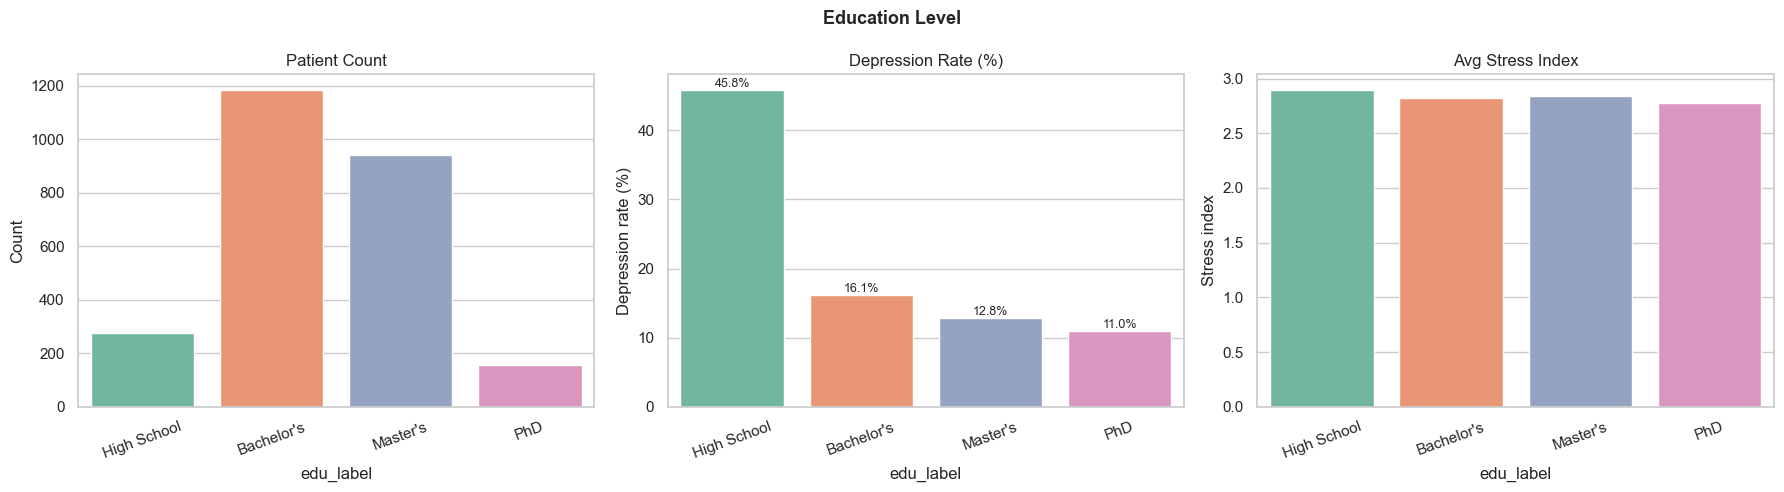

In [13]:
eda.plot_education(df)

##  Profession Category

Interesting that the other category is so high (students have already been filtered out). Could indicate that the profession feature isn't meaninful due to missing data.

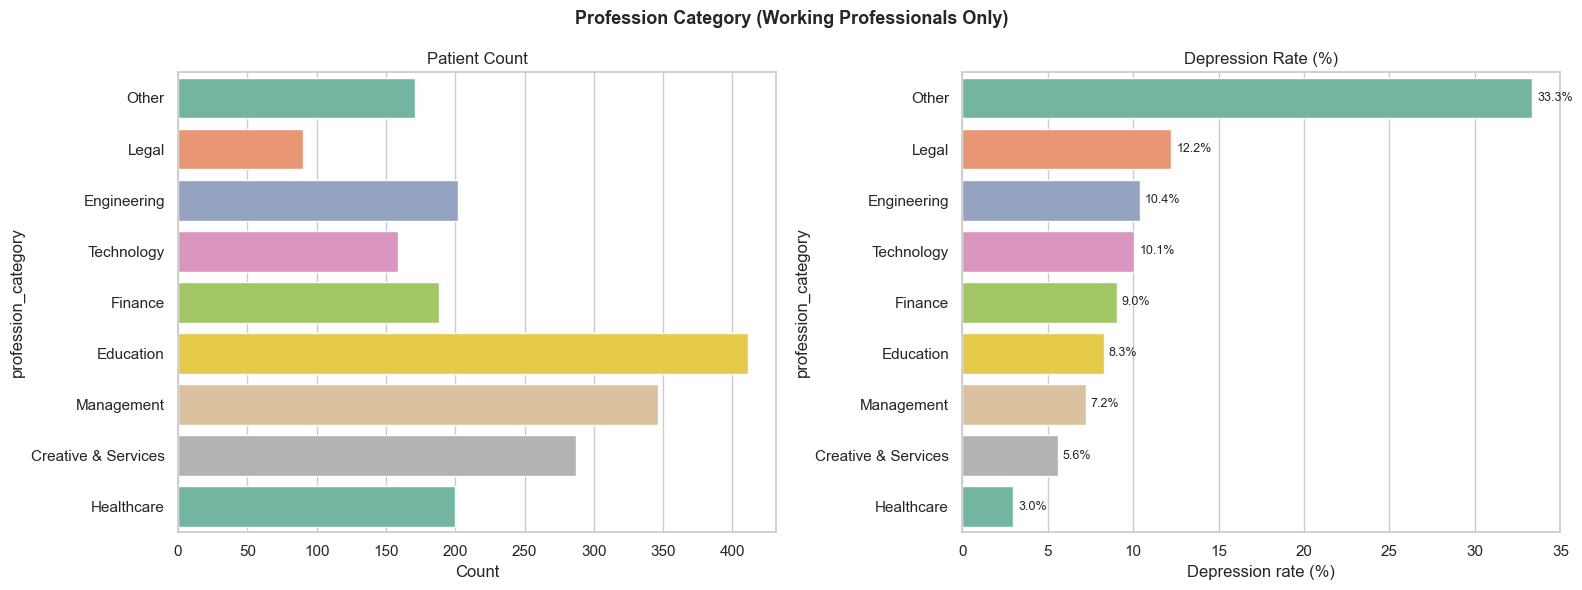

In [14]:
eda.plot_profession_category(df)

## Stress Index by Profession Category

Stress Index relatively similar across all professions

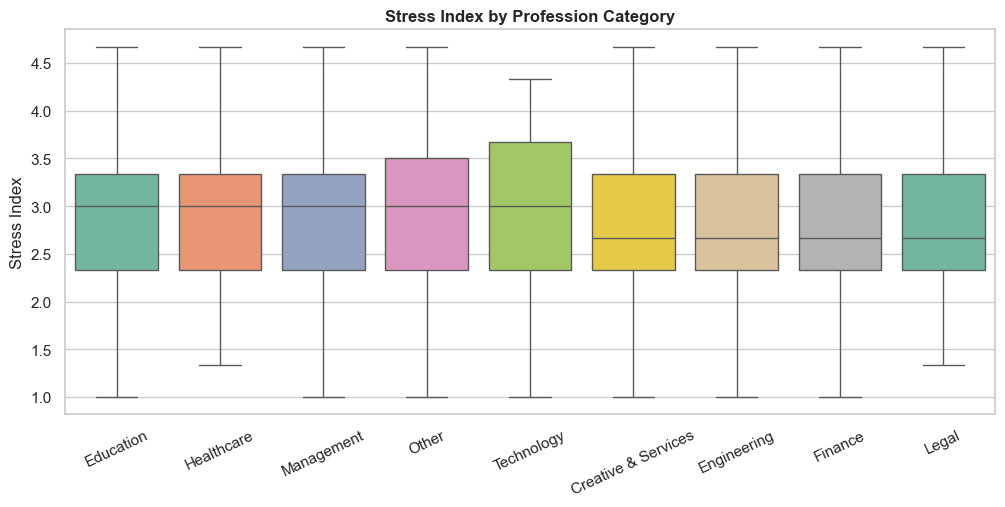

In [15]:
eda.plot_stress_by_profession(df)

## Depression Rate: Education x Profession Heatmap

The other category here could mean high school grad no job?

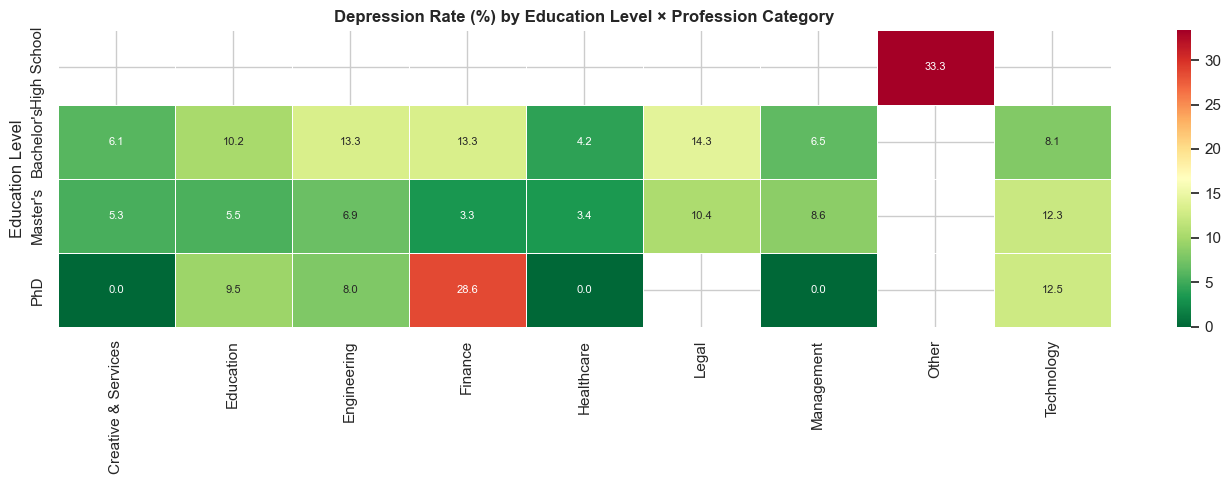

In [16]:
eda.plot_education_profession_heatmap(df)